## Задание
Продолжаем работать с объединенным датасетом merged_data

**Задача 1**

Цель: выделить пользователей, которые делают упор на индивидуальные тренировки.

Что сделать:
Выберите пользователей, у которых >70% тренировок — индивидуальные.
Для этих пользователей:
+ Посчитайте средний чек;
+ Посчитайте среднее число тренировок в месяц;
+ Разбейте их по городам и полу.

Вопросы для анализа:

+ Кто чаще выбирает индивидуальные тренировки?
+ Есть ли зависимость от пола или города?
+ Насколько высок средний чек у таких пользователей?

**Задача 2.**
Найдите 10 пользователей с наибольшим общим количеством посещений (групповые + индивидуальные тренировки) за весь период наблюдения.

Что нужно сделать:

+ Рассчитайте общее количество тренировок для каждого пользователя.

+ Определите 10 самых активных пользователей и сохраните их идентификаторы в виде списка.

Постройте распределение этих пользователей по:

+ городу
+ полу

Вопросы для анализа:
+ В каких городах больше всего супер-активных клиентов?
+ Какого они пола?

**Задача 3**
Ваша цель — проанализировать, как менялась клиентская база по месяцам:
сколько клиентов приходило, сколько уходило и сколько оставалось активными.

Шаги:
+ Новые клиенты — это те, у кого первый месяц появления (минимальный mon в данных).

+ Ушедшие клиенты — это те, у кого последний месяц активности (максимальный mon в данных).

+ Активные клиенты — это те, кто был активен в конкретном месяце.

Что нужно сделать:
Рассчитайте три метрики для каждого месяца:
+ new_clients: количество клиентов, для которых этот месяц — первый.
+ gone_clients: количество клиентов, для которых этот месяц — последний.
+ active_clients: общее количество уникальных клиентов в этом месяце.

Для этого:
Создайте три отдельных датафрейма:

+ с новыми клиентами по месяцам,
+ с ушедшими клиентами по месяцам,
+ с активными клиентами по месяцам.

Объедините их по полю mon.

Постройте линейный график с тремя линиями.

Подсказка:
+ Используйте groupby и nunique() для подсчёта количества клиентов.
+ Для объединения датафреймов — merge.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data (1).csv')
df.head(10)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
5,1000,2023-08,0,3,0,5400,3,5400,2023-03,2023-12,СПб,44.0,female
6,1000,2023-09,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
7,1000,2023-11,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
8,1000,2023-12,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female


### Задача 1. Пользователи с 70%+ инд.тренировок

In [82]:
#преобразуем в тип даты значения мин и макс месяца для будущих расчетов

df['min_mon'] = pd.to_datetime(df['min_mon'])
df['max_mon'] = pd.to_datetime(df['max_mon'])

In [83]:
#сделаем промежуточные расчеты для вывода необходимых метрик

indiv_users = df.groupby(['id_user', 'city', 'gender', 'min_mon', 'max_mon']).agg({'cnt_group':'sum',
                                        'cnt_indiv':'sum',
                                        'sum_group':'sum',
                                        'sum_indiv':'sum',
                                        'cnt_total':'sum',
                                        'sum_total':'sum'}).reset_index() # агрегируем пользователям суммы по количеству тренировок и чекам

indiv_users['share_indiv'] = indiv_users['cnt_indiv'] / indiv_users['cnt_total'] # считаем долю индивидуальных тренировок
indiv_users['mon_cnt'] = indiv_users['max_mon'].dt.month - indiv_users['min_mon'].dt.month #считаем количество месяцев, которые они отзанимались
indiv_users['mon_cnt'] = indiv_users['mon_cnt'].replace(0, 1) # учтем, что есть люди, которые занимались только 1 месяц.
# У них max_mon - min_mon может быть == 0, и тогда будет inf при делении на 0. Для избегания этого заменим 0 на 1.
indiv_users['avg_cnt_train'] = (indiv_users['cnt_total'] / indiv_users['mon_cnt']).round(2) # посчитаем среднее кол-во тренировок в месяц

final_indiv_users = indiv_users[indiv_users['share_indiv'] > 0.7] #выбираем только тех, у кого >70% тренировок - индивидуальные

final_indiv_users.head(10)

,id_user,city,gender,min_mon,max_mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,share_indiv,mon_cnt,avg_cnt_train
0,1000,СПб,female,2023-03-01,2023-12-01,0,33,0,58600,33,58600,1.0,9,3.67
3,1004,Екатеринбург,male,2023-02-01,2023-10-01,0,18,0,32000,18,32000,1.0,8,2.25
4,1005,СПб,female,2023-07-01,2023-10-01,0,7,0,12600,7,12600,1.0,3,2.33
6,1007,Москва,female,2023-01-01,2023-04-01,0,5,0,9000,5,9000,1.0,3,1.67
8,1009,Москва,female,2023-06-01,2023-09-01,0,9,0,16200,9,16200,1.0,3,3.00
11,1012,Москва,female,2023-01-01,2023-12-01,0,6,0,10800,6,10800,1.0,11,0.55
15,1016,Москва,female,2023-01-01,2023-01-01,0,4,0,7200,4,7200,1.0,1,4.00
16,1017,СПб,female,2023-12-01,2023-12-01,0,6,0,10800,6,10800,1.0,1,6.00
17,1018,Екатеринбург,female,2023-08-01,2023-11-01,0,18,0,32400,18,32400,1.0,3,6.00
18,1019,Москва,male,2023-01-01,2023-12-01,0,31,0,55000,31,55000,1.0,11,2.82


In [84]:
# Посчитайте средний чек;
# Посчитайте среднее число тренировок в месяц;
# Разбейте их по городам и полу.


# строим итоговую сводную таблицу

final_indiv_users_table = pd.pivot_table(
    final_indiv_users,
    index = 'city',
    columns = 'gender',
    aggfunc = {
        'sum_total' : 'mean',
        'avg_cnt_train' : 'mean'
    }
) 

final_indiv_users_table

avg_cnt_train               sum_total              
gender              female      male        female          male
city                                                            
Екатеринбург      3.259167  4.509167  25616.666667  27366.666667
Казань            3.285000  3.107500  18000.000000  24633.333333
Москва            3.718136  4.782203  22400.000000  25881.355932
СПб               4.025625  3.424643  28162.500000  18657.142857

In [85]:
#Вопрос: Кто чаще выбирает индивидуальные тренировки?

print(final_indiv_users['gender'].value_counts())

# ответ: чаще индив. тренировки выбирают женщины, что можно наглядно наблюдать в любом тренажерном зале.

gender
female    170
male      111
Name: count, dtype: int64


In [ ]:
#Вопрос: Есть ли зависимость от пола или города?

# ответ: Как видно из final_indiv_users_table, в среднем количество индивид. тренировок в месяц и у мужчин, и у женщин почти совпадает 
# (3,56 у женщин и 3,95 у мужчин). То есть перевес у мужчин не такой уж и критичный.
# Но если смотреть по городам, то есть есть некоторое разделение: в Екб и Мск в среднем чаще тренируются мужчины,
# а в Казани и СПб чаще тренируются женщины 



In [ ]:
#Вопрос: Насколько высок средний чек у таких пользователей?

# ответ: Средний чек у таких пользователей с 70+% индививидуальных тренировок от общего их числа сильно разнится от города к городоу.
# в среднем по всем гордам у женщин средний чек получается 23 544 рубля, у мужчин - 24 134. Практически одинаковый.

### Задача 2. Топ-10 клиентов

In [86]:
top_users = df.groupby(['id_user', 'city', 'gender']).agg({'cnt_total' : 'sum'}).reset_index() #найдем пользователей с максимальным 
#количеством тренировок

top_users = top_users.sort_values(by = 'cnt_total', ascending = False).reset_index().head(10) # отсортируем их и оставим первые 10 штук

top_users

,index,id_user,city,gender,cnt_total
0,319,1381,Москва,female,159
1,12,1013,Москва,male,151
2,551,1657,СПб,male,144
3,420,1506,Москва,female,138
4,780,1929,Москва,male,130
5,1,1001,Москва,female,129
6,474,1570,Екатеринбург,male,129
7,2,1002,Москва,male,128
8,485,1582,Екатеринбург,male,127
9,168,1194,СПб,female,127


In [87]:
top_users_lst = top_users['id_user'].to_list() # запишем id пользователей в список

top_users_lst

[1381, 1013, 1657, 1506, 1929, 1001, 1570, 1002, 1582, 1194]

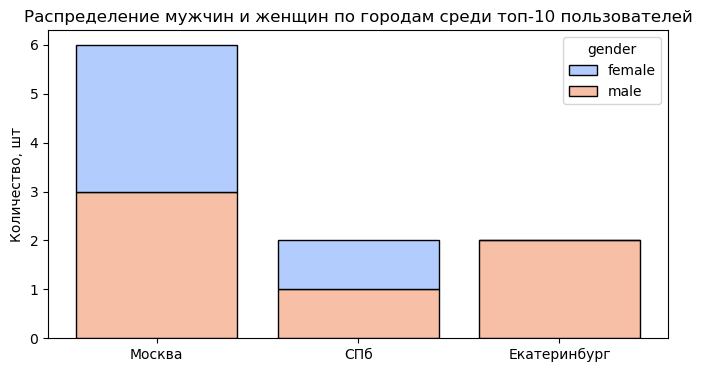

In [88]:
# Постройте распределение этих пользователей по: городу и полу

plt.figure(figsize=(8, 4))

sns.histplot(
    data = top_users,
    x = 'city',
    hue = 'gender',
    multiple = 'stack',   
    discrete = True,       
    shrink = 0.8,          
    alpha = 0.9,           
    palette='coolwarm'
)

plt.title('Распределение мужчин и женщин по городам среди топ-10 пользователей')
plt.ylabel('Количество, шт')
plt.xlabel('')
plt.show()

In [ ]:
Вопросы для анализа:

В каких городах больше всего супер-активных клиентов?
Ответ: Больше всего их всего в трех городах: Мск, СПб и Екб.

Какого они пола?
Ответ: В Мск и СПб мужчин и женщин поровну, а вот в Екб среди самых активных клиентов встречаются только мужчины.

### Задача 3. Динамика клиентской базы

In [89]:
#Посмотрим, как сейчас выглядит df
df


,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03-01,2023-12-01,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03-01,2023-12-01,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03-01,2023-12-01,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03-01,2023-12-01,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03-01,2023-12-01,СПб,44.0,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4586,1997,2023-08,4,0,3200,0,4,3200,2023-01-01,2023-12-01,СПб,58.0,male
4587,1997,2023-09,6,0,4800,0,6,4800,2023-01-01,2023-12-01,СПб,58.0,male
4588,1997,2023-10,6,0,4800,0,6,4800,2023-01-01,2023-12-01,СПб,58.0,male
4589,1997,2023-11,6,0,4800,0,6,4800,2023-01-01,2023-12-01,СПб,58.0,male


In [90]:
#Видим, что колонки min_mon и max_mon имеют тип datetime, а для merge потом нужно будет их привести снова к object.
#подгрузим заново df, чтобы обнулить преобразование min_mon и max_mon

df = pd.read_csv('merged_data (1).csv')
df.head(10)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
5,1000,2023-08,0,3,0,5400,3,5400,2023-03,2023-12,СПб,44.0,female
6,1000,2023-09,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
7,1000,2023-11,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
8,1000,2023-12,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female


In [91]:
#считаем новых клиентов
clients_new = (
        df
        .groupby('min_mon')['id_user']
        .nunique('id_user')
        .reset_index()
        .rename(columns = {'id_user': 'cnt_new_users', 'min_mon' : 'month'})
)
clients_new

,month,cnt_new_users
0,2023-01,337
1,2023-02,88
2,2023-03,83
3,2023-04,62
4,2023-05,57
5,2023-06,51
6,2023-07,48
7,2023-08,35
8,2023-09,28
9,2023-10,27


In [92]:
#считаем активных клиентов
clients_active = (
    df
    .groupby('mon')['id_user']
    .nunique('id_user')
    .reset_index()
    .rename(columns = {'id_user': 'cnt_active_users', 'mon' : 'month'})
)

clients_active

,month,cnt_active_users
0,2023-01,337
1,2023-02,350
2,2023-03,355
3,2023-04,345
4,2023-05,360
5,2023-06,383
6,2023-07,412
7,2023-08,423
8,2023-09,429
9,2023-10,441


In [93]:
#считаем ушедших клиентов

clients_gone = (
        df
        .groupby('max_mon')['id_user']
        .nunique('id_user')
        .reset_index()
        .rename(columns = {'id_user': 'cnt_gone_users', 'max_mon' : 'month'})
)
clients_gone

,month,cnt_gone_users
0,2023-01,15
1,2023-02,22
2,2023-03,37
3,2023-04,21
4,2023-05,21
5,2023-06,13
6,2023-07,33
7,2023-08,33
8,2023-09,55
9,2023-10,101


In [94]:
#объединяем все в один датафрейм

clients_new_and_active = pd.merge(clients_new, clients_active, on = 'month', how = 'inner')
clients_all = pd.merge(clients_new_and_active, clients_gone, on = 'month', how = 'inner')

clients_all


,month,cnt_new_users,cnt_active_users,cnt_gone_users
0,2023-01,337,337,15
1,2023-02,88,350,22
2,2023-03,83,355,37
3,2023-04,62,345,21
4,2023-05,57,360,21
5,2023-06,51,383,13
6,2023-07,48,412,33
7,2023-08,35,423,33
8,2023-09,28,429,55
9,2023-10,27,441,101


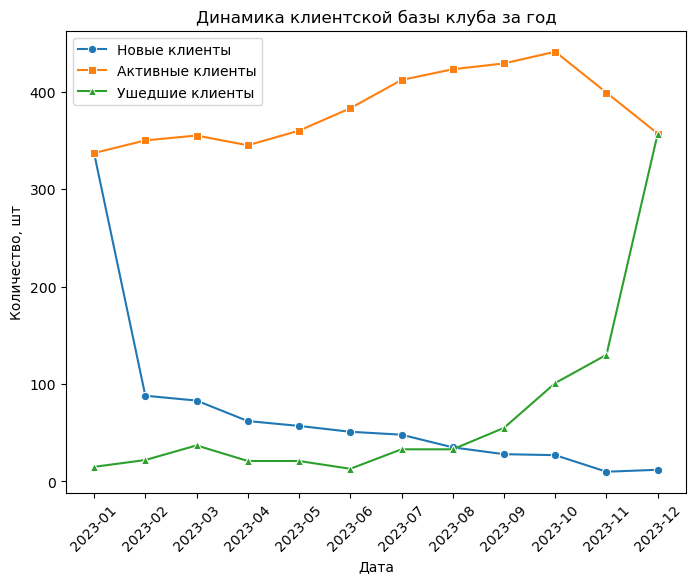

In [99]:
#Построим линейный график с тремя линиями.

fig, ax = plt.subplots(figsize=(8, 6))

sns.lineplot(data = clients_all, x = 'month', y = 'cnt_new_users', ax = ax, label = 'Новые клиенты', marker='o')
sns.lineplot(data = clients_all, x = 'month', y = 'cnt_active_users', ax = ax, label = 'Активные клиенты', marker='s')
sns.lineplot(data = clients_all, x = 'month', y = 'cnt_gone_users', ax = ax, label = 'Ушедшие клиенты', marker='^')

ax.set_title('Динамика клиентской базы клуба за год')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество, шт')
ax.legend()
plt.xticks(rotation=45)
plt.show()
